# Zavšni projekat iz mašinskog učenja

*Milan Zeljković*

*Broj indeksa - 2020204144*

## Deo 1

### Linearna regresija od nule

Problem:

Vaš zadatak je da implementirate linearnu regresiju od nule koristeći gradijentni spust. Treba da radite sa skupom podataka koji sadrži više karakteristika. Da bi zadatak bio zanimljiviji, uključićete polinomske karakteristike.

**Implementacija:**

* *Implementirati linearnu regresiju koristeći gradijentni spust.*

* *Primeniti polinomsku transformaciju stepena 2 na ulazne karakteristike. Ovo znači da treba uključiti kvadratne vrednosti ulaznih karakteristika u model.*

* *Koristiti srednju kvadratnu grešku (MSE) kao funkciju greške.*

* *Napisati kod za izračunavanje gradijenta i ažuriranje težina modela.*

**Vizuelizacija:**

* *Nacrtati grafikon funkcije greške (MSE) u zavisnosti od broja epoha tokom treniranja. Ovo će vam pomoći da vizualizujete kako model konvergira tokom iteracija.*

**Skup podataka:**

* *Možete generisati sintetičke podatke ili koristiti neki realni skup podataka sa više karakteristika.*

* *Ako koristite sintetičke podatke, generišite podatke gde je poznata prava veza, na primer: y= 3x_1 + 2x_2^2 + 4 za dve karakteristike x₁ i x₂.*

**Pitanja:**

* *Kako polinomske karakteristike utiču na model regresije?*

* *Šta se dešava sa funkcijom greške kada se stepen polinoma povećava?*

* *Kako izbor stope učenja utiče na konvergenciju modela tokom treniranja?*

#### Importovanje biblioteka

U ovom delu importujemo neophodne biblioteke za rad. Takođe se postavlja random.seed().

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [150]:
np.random.seed(42)

#### Generisanje sintetičkih podataka

Generisati podatke gde je poznata prava veza. Prava veza definisana je formulom:

$$y = 3x_1 + 2x_2^2 + 4 + \text{noise}$$

Na ovaj način dobija se nelinearnost, pa je potrebno koristiti polinomske karakteristike.

In [151]:
# Veličina skupa
m = 200

In [152]:
# Dve ulazne karakteristike, x1 i x2
x1 = np.random.uniform(-3, 3, m)
x2 = np.random.uniform(-3, 3, m)
x1.shape, x2.shape

((200,), (200,))

In [153]:
# noise - šum
noise = np.random.randn(m)
noise.shape

(200,)

#### Hipoteza

$$y = 3x_1 + 2x_2^2 + 4 + \text{noise}$$

In [154]:
y = 3*x1 + 2 * (x2 ** 2) + 4 + noise

#### Formatiranje matrice ulaznih podataka

Ulazne karakteristike se spajaju u jednu matricu oblika:

$$X = [x_1, x_2]$$

Svaki red predstavlja jedan primer (sample), dok kolone predstavljaju karakteristike (feature).

In [185]:
"""
  Ovo je moguće uraditi na više načina:
    1. np.column_stack((x1, x2)) - najjednostavniji način
    2. np.c_[x1, x2] - isto kao i ovo gore, samo nije metoda, nego property
    3. np.hstack - horizontalni stack, pa zahteva reshape da bih prebacilo u 2D
    4. np.concatenate - praktično radi isto što i np.hstack, takođe mora da se uradi reshape
"""

X_start = np.hstack((x1.reshape(-1, 1), x2.reshape(-1, 1)))
print(f"Ispis prvih par redova X matrice:\n\n{X[:5]}")
print(f"\nPrikaz dimenzija X matrice, očekivan rezultat je 200 x 2, a stvarna dimenzija je: {X_start.shape}")

Ispis prvih par redova X matrice:

[[ 1.         -0.37213971  0.47099449]
 [ 1.          1.58661523 -1.43784301]
 [ 1.          0.84305607 -1.17271371]
 [ 1.          0.38977043  1.34869148]
 [ 1.         -1.11502273  0.34917953]]

Prikaz dimenzija X matrice, očekivan rezultat je 200 x 2, a stvarna dimenzija je: (200, 2)


#### Standardizacija podataka

Kod gradient descent algoritma, standardizacija je često bolja zato što:

* Gradijent se stabilnije računa
* Feature-i imaju sličnu skalu
* Optimizacija brže konvergira


In [156]:
def standardize(X):
  mean = np.mean(X, axis=0) # Uzima srednju vrednost po svakoj koloni
  std = np.std(X, axis=0) # Uzima standardnu devijaciju po svakoj koloni

  X_scaled = (X - mean) / std
  return X_scaled, mean, std

In [157]:
X_scaled, X_mean, X_std = standardize(X_start)

#### Dodavanje bias-a

Bias predstavlja slobodan član modela, i omogućava da funkcija ne mora prolaziti kroz koordinatni početak. Dodaje se kao kolona jedinica na početak matrice ulaznih karakteristika (feature-a).
Bias se dodaje nakon standardizacije, jer je on kolona u kojoj se nalaze samo jedinice, pa sama standardizacija nema nikakvog efekta na njega, pošto su svi elementi niza isti, nema nikakve varijacije, pa bi i standardna devijacija bila 0, a to bi izazvalo problem pri standardizaciji zbog deljenja sa 0.

In [158]:
def add_bias(X):
  m = X.shape[0] # Uzima koliko samplova ima u glavnoj matrici
  ones = np.ones((m, 1))
  return np.hstack((ones, X))

In [159]:
X = add_bias(X_scaled)
print(f"Nakon dodate kolone bias:\n\n{X[:5]}")
print(f"\n Oblik matrice: {X.shape}")

Nakon dodate kolone bias:

[[ 1.         -0.37213971  0.47099449]
 [ 1.          1.58661523 -1.43784301]
 [ 1.          0.84305607 -1.17271371]
 [ 1.          0.38977043  1.34869148]
 [ 1.         -1.11502273  0.34917953]]

 Oblik matrice: (200, 3)


#### Implementacija funkcije predikcije

In [160]:
def predict_linear(X, theta):
  return X @ theta # matricno množenje, moglo je i sa dot

In [161]:
# Nakon dodavanja bias-a na standardizovanu matricu, dimenzija se promenila u 200 x 3
# Da bi matrica X mogla da se pomnoži sa inicijalnom matricom theta, dimenzije moraju da se poklapaju
theta_test = np.zeros(X.shape[1])
theta_test.shape

(3,)

In [162]:
y_predict_test = predict_linear(X, theta_test)
print(y_predict_test[:5])

[0. 0. 0. 0. 0.]


#### Funkcija greške (MSE)


$$MSE = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2$$


In [163]:
def mse(y_true, y_predict):
  m = len(y_true)
  return (1/m) * np.sum((y_predict - y_true)**2)

In [164]:
theta_test = np.zeros(X.shape[1])
y_predict_test = predict_linear(X, theta_test)
loss_test = mse(y, y_predict_test)
print(f"Inicijalna MSE: {loss_test}, bez optimizovanih vrednosti theta.")

Inicijalna MSE: 150.00555079975152, bez optimizovanih vrednosti theta.


#### Računanje gradijenta

Gradijent funkcije greške određuje smer i intenzitet promene parametara modela.
Za linearnu regresiju:

$$\nabla J(\theta)=\frac{2}{m}X^T(\hat{y}-y)$$

In [165]:
def compute_gradient_linear(X, y_real, y_predicted):
  m = len(y_real)
  gradient = (2/m) * (X.T @ (y_predicted - y_real))
  return gradient

In [166]:
gradient_test = compute_gradient_linear(X, y, y_predict_test)

print(gradient_test)
print(gradient_test.shape)

[-19.71917314  -9.16908781   1.59951042]
(3,)


#### Gradient descent

Gradient descent iterativno ažurira parametre modela kako bi minimizovao funkciju greške.

U svakoj epohi, vrši se:


1.   Predikcija
2.   Računanje MSE
3.   Računanje gradijenta
4.   Ažuriranje težina ($\theta$)

Ažuriranje se vrši formulom:

$$\theta := \theta - \alpha \nabla J(\theta)$$

Gde je:
- $\alpha$ - stopa učenja
- $\nabla J(\theta)\$ gradijent funkcije greške

In [167]:
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
  n_features = X.shape[1]

  theta = np.zeros(n_features)

  loss_history = []

  for epoch in range(epochs):
    y_predict = predict_linear(X, theta)
    loss = mse(y, y_predict)
    gradient = compute_gradient_linear(X, y, y_predict)
    theta = theta - learning_rate * gradient # Model ovde uči
    loss_history.append(loss)

  return theta, loss_history

#### Treniranje modela

In [168]:
theta_linear, loss_history_linear = gradient_descent(X, y, learning_rate=0.01, epochs=2000)

In [169]:
final_predictions = predict_linear(X, theta_linear)
final_mse = mse(y, final_predictions)

print(f"Naučene težine:\n\n{theta_linear}\n")
print(f"Finalni MSE: {final_mse}")

Naučene težine:

[ 9.85958657  4.56634188 -0.67697945]

Finalni MSE: 31.31809075312697


#### Vizuelizacija funkcije greške

Grafikon prikazuje promenu MSE funkcije greške kroz epohe tokom treniranja modela. Ako greška opada, model uspešno konvergira ka minimumu.

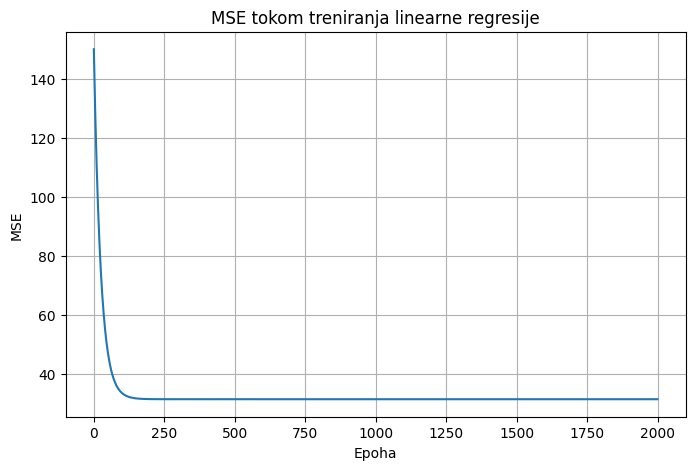

In [170]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_linear)

plt.xlabel("Epoha")
plt.ylabel("MSE")
plt.title("MSE tokom treniranja linearne regresije")
plt.grid(True)

In [180]:
from ipywidgets.widgets.widget_int import IntSlider
@widgets.interact(
    learning_rate = widgets.FloatSlider(value=0.01, min=0.0001, max=0.3,  step=0.0001, readout_format='.4f'),
    epochs        = widgets.IntSlider  (value=2000, min=10,    max=3000, step=10)
)
def plot_mse(learning_rate, epochs):
    _, loss_history = gradient_descent(X, y, learning_rate, epochs)

    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, color='steelblue', linewidth=2)
    plt.xlabel("Epoha")
    plt.ylabel("MSE")
    plt.title(f"Learning rate={learning_rate} | Epohe={epochs}")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=0.01, description='learning_rate', max=0.3, min=0.0001, readout_format…

### Polinomska transformacija stepena 2

Hipoteza:
$$y = 3x_1 + 2x_2^2 + 4 + \text{noise}$$

Pošto $y$ zavisi od kvadratnog člana $x_2^2$, uvodi se polinomska transformacija stepena 2.



Za dve ulazne karakteristike $x_1$ i $x_2$, formiraju se sledeće nove karakteristike:

- $x_1$
- $x_2$
- $x_1^2$
- $x_2^2$
- $x_1x_2$

In [172]:
def polynomial_transformation(X):
  x1 = X[:, 0]
  x2 = X[:, 1]

  return np.column_stack((x1, x2, x1**2, x2**2, x1 * x2))

In [173]:
X_poly = polynomial_transformation(X_start)
print(f"Prvih 5 redova X_poly:\n\n{X_poly[:5]}\n")
print(f"Oblik matrice X_poly: {X_poly.shape}")

Prvih 5 redova X_poly:

[[-0.75275929  0.85218988  0.56664654  0.72622759 -0.64149384]
 [ 2.70428584 -2.49516021  7.3131619   6.22582447 -6.74762642]
 [ 1.39196365 -2.03022772  1.93756281  4.12182458 -2.82600318]
 [ 0.59195091  2.39132513  0.35040587  5.71843588  1.41554708]
 [-2.06388816  0.63857436  4.25963433  0.40777721 -1.31794605]]

Oblik matrice X_poly: (200, 5)


#### Standardizacija polinomskih feature-a

Pošto polinomski feature-i mogu imati veće vrednosti od originalnih ulaza, potrebno ih je standardizovati pre treniranja modela.

Ovaj korak omogućava stabilniju i bržu konvergenciju gradient descent-a.

In [174]:
X_poly_scaled, X_poly_mean, X_poly_std = standardize(X_poly)
print(f"Prvih 5 redova standardizovanih polinomskih feature-a:\n\n{X_poly_scaled[:5]}\n")
print(f"Oblik matrice X_poly_scaled: {X_poly_scaled.shape}")

Prvih 5 redova standardizovanih polinomskih feature-a:

[[-0.37213971  0.47099449 -0.97737975 -0.84920702 -0.17869967]
 [ 1.58661523 -1.43784301  1.60087943  1.13849337 -2.14207278]
 [ 0.84305607 -1.17271371 -0.45346818  0.37805192 -0.88110939]
 [ 0.38977043  1.34869148 -1.06001863  0.95510965  0.48272371]
 [-1.11502273  0.34917953  0.43393842 -0.96430345 -0.39620691]]

Oblik matrice X_poly_scaled: (200, 5)


#### Dodavanje bias-a

In [175]:
X_poly_final = add_bias(X_poly_scaled)
print(f"Prvih 5 redova sa dodatom bias kolonom:\n\n{X_poly_final[:5]}\n")
print(f"Oblik matrice X_poly_final: {X_poly_final.shape}")

Prvih 5 redova sa dodatom bias kolonom:

[[ 1.         -0.37213971  0.47099449 -0.97737975 -0.84920702 -0.17869967]
 [ 1.          1.58661523 -1.43784301  1.60087943  1.13849337 -2.14207278]
 [ 1.          0.84305607 -1.17271371 -0.45346818  0.37805192 -0.88110939]
 [ 1.          0.38977043  1.34869148 -1.06001863  0.95510965  0.48272371]
 [ 1.         -1.11502273  0.34917953  0.43393842 -0.96430345 -0.39620691]]

Oblik matrice X_poly_final: (200, 6)


#### Treniranje polinomijalnog modela

In [176]:
theta_poly, loss_history_poly = gradient_descent(X_poly_final, y, learning_rate=0.01, epochs=2000)

In [177]:
final_predictions_poly = predict_linear(X_poly_final, theta_poly)
final_mse_poly = mse(y, final_predictions_poly)

print(f"Naučene težine:\n\n{theta_poly}\n")
print(f"Finalni MSE: {final_mse_poly}")

Naučene težine:

[ 9.85958657e+00  5.30066415e+00 -5.73391121e-02 -1.45808449e-01
  5.59156550e+00 -7.86950463e-03]

Finalni MSE: 0.943697547574026


In [178]:
@widgets.interact(
    learning_rate = widgets.FloatSlider(value=0.01, min=0.0001, max=0.3,  step=0.0001, readout_format='.4f'),
    epochs        = widgets.IntSlider  (value=2000, min=10,    max=3000, step=10)
)
def plot_mse(learning_rate, epochs):
    _, loss_history = gradient_descent(X_poly_final, y, learning_rate, epochs)

    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, color='steelblue', linewidth=2)
    plt.xlabel("Epoha")
    plt.ylabel("MSE")
    plt.title(f"Learning rate={learning_rate} | Epohe={epochs}")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=0.01, description='learning_rate', max=0.3, min=0.0001, readout_format…

### Poređenje performansi linearnog i polinomijalnog modela

Poredimo vrednost MSE za:
* osnovni linearni model
* model sa polinomskim karakteristikama stepena 2

Manja vrednost MSE ukazuje na bolju aproksimaciju stvarne funkcije.

In [179]:
print(f"MSE osnovnog linearnog modela: {final_mse}")
print(f"MSE polinomijalnog modela drugog stepena: {final_mse_poly}")

MSE osnovnog linearnog modela: 31.31809075312697
MSE polinomijalnog modela drugog stepena: 0.943697547574026


### Odgovori na pitanja

**Pitanje:** *Kako polinomske karakteristike utiču na model regresije?*

**Odgovor:** *Polinomske karakteristike omogućavaju da se opišu nelinearni odnosi između ulaznih podataka i izlaza.*



---


**Pitanje:** *Šta se dešava sa funkcijom greške kada se stepen polinoma povećava?*

**Odgovor:** *Povećanjem stepena polinoma model dobija više karakteristika i postaje fleksibilniji.
To obično dovodi do smanjenja greške na trening podacima, jer model može preciznije da aproksimira odnos između ulaza i izlaza.
Međutim, prevelik stepen polinoma može dovesti do overfitting-a, odnosno situacije kada model previše prilagodi trening podatke i slabije generalizuje nove podatke.
U ovom primeru polinomijalna transformacija drugog stepena daje bolji rezultat od osnovnog linearnog modela, jer odgovara stvarnoj strukturi podataka.*


---


**Pitanje:** *Kako izbor stope učenja utiče na konvergenciju modela tokom treniranja?*

**Odgovor:** *Stopa učenja određuje veličinu koraka kojim se parametri modela ažuriraju tokom gradijentnog spusta.*
*Ako je stopa učenja previše mala:*
* *model konvergira veoma sporo*
* *potrebno je više epoha*

*Ako je stopa učenja prevelika:*
* *model može preskakati minimum*
* *funkcija greške može oscilovati ili rasti*

*U ovom projektu korišćena je vrednost learning rate = 0.01, koja omogućava stabilno opadanje MSE kroz epohe i uspešnu konvergenciju modela.*